In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df1 = pd.read_csv(r"O:\ITI\DEP\Penguins\table_219_Adelie.csv")
df2 = pd.read_csv(r"O:\ITI\DEP\Penguins\table_220_Gentoo.csv")
df3 = pd.read_csv(r"O:\ITI\DEP\Penguins\table_221_Chinstrap.csv")

In [4]:
df = pd.concat([df1, df2, df3], ignore_index=True)
df.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,2007-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


In [5]:
df[df.duplicated()]

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    object 
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    object 
 3   Region               344 non-null    object 
 4   Island               344 non-null    object 
 5   Stage                344 non-null    object 
 6   Individual ID        344 non-null    object 
 7   Clutch Completion    344 non-null    object 
 8   Date Egg             344 non-null    object 
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    object 
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    flo

In [7]:
df['Date Egg'] = pd.to_datetime(df['Date Egg'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   studyName            344 non-null    object        
 1   Sample Number        344 non-null    int64         
 2   Species              344 non-null    object        
 3   Region               344 non-null    object        
 4   Island               344 non-null    object        
 5   Stage                344 non-null    object        
 6   Individual ID        344 non-null    object        
 7   Clutch Completion    344 non-null    object        
 8   Date Egg             344 non-null    datetime64[ns]
 9   Culmen Length (mm)   342 non-null    float64       
 10  Culmen Depth (mm)    342 non-null    float64       
 11  Flipper Length (mm)  342 non-null    float64       
 12  Body Mass (g)        342 non-null    float64       
 13  Sex                  334 non-null  

In [9]:
df.describe()

,Sample Number,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
count,344.000000,344,342.000000,342.000000,342.000000,342.000000,330.000000,331.000000
mean,63.151163,2008-11-27 03:46:02.790697728,43.921930,17.151170,200.915205,4201.754386,8.733382,-25.686292
min,1.000000,2007-11-09 00:00:00,32.100000,13.100000,172.000000,2700.000000,7.632200,-27.018540
25%,29.000000,2007-11-28 00:00:00,39.225000,15.600000,190.000000,3550.000000,8.299890,-26.320305
50%,58.000000,2008-11-09 00:00:00,44.450000,17.300000,197.000000,4050.000000,8.652405,-25.833520
75%,95.250000,2009-11-16 00:00:00,48.500000,18.700000,213.000000,4750.000000,9.172123,-25.062050
max,152.000000,2009-12-01 00:00:00,59.600000,21.500000,231.000000,6300.000000,10.025440,-23.787670
std,40.430199,NaN,5.459584,1.974793,14.061714,801.954536,0.551770,0.793961


In [10]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].value_counts()}")

studyName: studyName
PAL0910    120
PAL0809    114
PAL0708    110
Name: count, dtype: int64
Species: Species
Adelie Penguin (Pygoscelis adeliae)          152
Gentoo penguin (Pygoscelis papua)            124
Chinstrap penguin (Pygoscelis antarctica)     68
Name: count, dtype: int64
Region: Region
Anvers    344
Name: count, dtype: int64
Island: Island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
Stage: Stage
Adult, 1 Egg Stage    344
Name: count, dtype: int64
Individual ID: Individual ID
N6A1      3
N6A2      3
N13A2     3
N13A1     3
N8A2      3
         ..
N98A2     1
N99A1     1
N99A2     1
N100A1    1
N100A2    1
Name: count, Length: 190, dtype: int64
Clutch Completion: Clutch Completion
Yes    308
No      36
Name: count, dtype: int64
Sex: Sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64
Comments: Comments
Nest never observed with full clutch.                                   34
Not enough blood for isotopes.                    

In [11]:
df[df['Sex'] == '.']

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
268,PAL0910,117,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N36A1,Yes,2009-12-01,44.5,15.7,217.0,4875.0,.,8.04111,-26.18444,Sexing primers did not amplify.


In [12]:
import numpy as np
df['Sex'] = df['Sex'].replace('.', np.nan)

In [13]:
df.isna().sum()

studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       2
Culmen Depth (mm)        2
Flipper Length (mm)      2
Body Mass (g)            2
Sex                     11
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               290
dtype: int64

In [14]:
df.drop(columns=['Comments'], inplace=True)

In [15]:
df.drop(columns=['Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Stage', 'Region'], inplace=True)

In [16]:
df[df.isna().any(axis=1)]

,studyName,Sample Number,Species,Island,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Torgersen,N2A2,Yes,2007-11-16,NaN,NaN,NaN,NaN,NaN
8,PAL0708,9,Adelie Penguin (Pygoscelis adeliae),Torgersen,N5A1,Yes,2007-11-09,34.1,18.1,193.0,3475.0,NaN
9,PAL0708,10,Adelie Penguin (Pygoscelis adeliae),Torgersen,N5A2,Yes,2007-11-09,42.0,20.2,190.0,4250.0,NaN
10,PAL0708,11,Adelie Penguin (Pygoscelis adeliae),Torgersen,N6A1,Yes,2007-11-09,37.8,17.1,186.0,3300.0,NaN
11,PAL0708,12,Adelie Penguin (Pygoscelis adeliae),Torgersen,N6A2,Yes,2007-11-09,37.8,17.3,180.0,3700.0,NaN
47,PAL0708,48,Adelie Penguin (Pygoscelis adeliae),Dream,N29A2,Yes,2007-11-13,37.5,18.9,179.0,2975.0,NaN
178,PAL0708,27,Gentoo penguin (Pygoscelis papua),Biscoe,N46A1,Yes,2007-11-29,44.5,14.3,216.0,4100.0,NaN
218,PAL0809,67,Gentoo penguin (Pygoscelis papua),Biscoe,N51A1,Yes,2008-11-09,46.2,14.4,214.0,4650.0,NaN
256,PAL0910,105,Gentoo penguin (Pygoscelis papua),Biscoe,N24A1,Yes,2009-12-01,47.3,13.8,216.0,4725.0,NaN
268,PAL0910,117,Gentoo penguin (Pygoscelis papua),Biscoe,N36A1,Yes,2009-12-01,44.5,15.7,217.0,4875.0,NaN


In [17]:
df.dropna(inplace=True)

In [18]:
df['Species'] = df['Species'].apply(lambda x: x.split())

In [19]:
df['Species'] = df['Species'].apply(lambda x: x[0])
df


,studyName,Sample Number,Species,Island,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,PAL0708,1,Adelie,Torgersen,N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE
1,PAL0708,2,Adelie,Torgersen,N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE
2,PAL0708,3,Adelie,Torgersen,N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE
4,PAL0708,5,Adelie,Torgersen,N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE
5,PAL0708,6,Adelie,Torgersen,N3A2,Yes,2007-11-16,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...,...,...,...,...,...
339,PAL0910,64,Chinstrap,Dream,N98A2,Yes,2009-11-19,55.8,19.8,207.0,4000.0,MALE
340,PAL0910,65,Chinstrap,Dream,N99A1,No,2009-11-21,43.5,18.1,202.0,3400.0,FEMALE
341,PAL0910,66,Chinstrap,Dream,N99A2,No,2009-11-21,49.6,18.2,193.0,3775.0,MALE
342,PAL0910,67,Chinstrap,Dream,N100A1,Yes,2009-11-21,50.8,19.0,210.0,4100.0,MALE


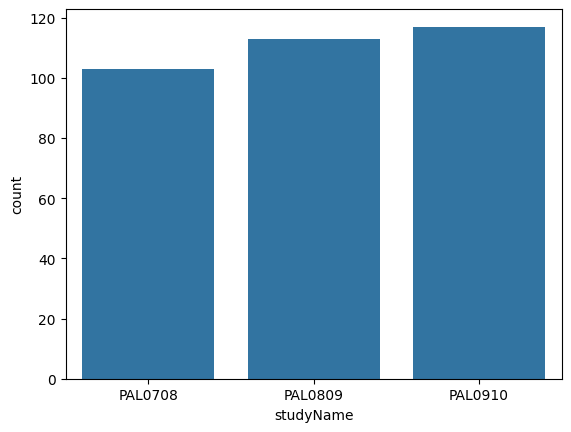

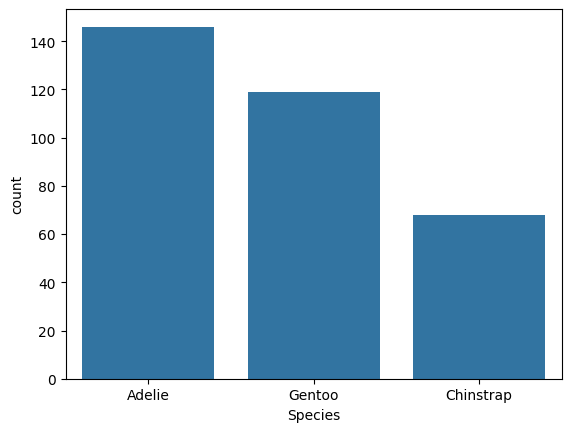

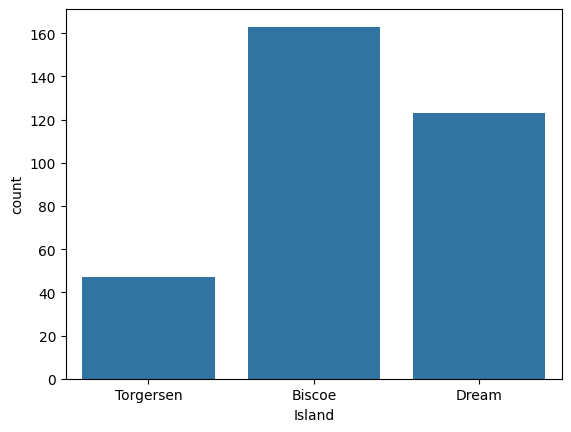

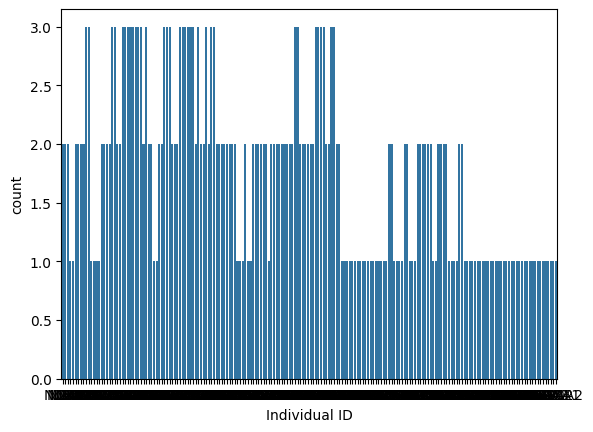

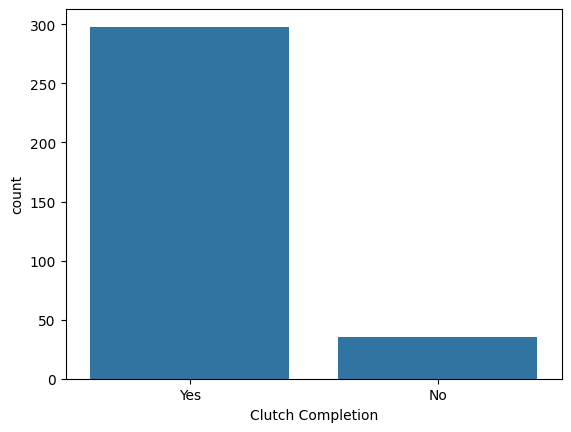

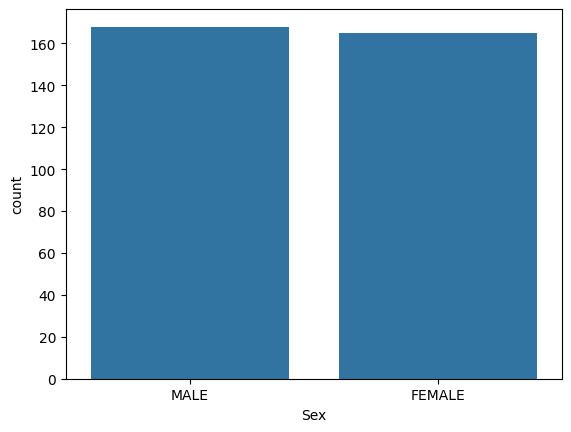

In [20]:
for col in df.select_dtypes(include='object').columns:
    sns.countplot(data=df, x=col)
    plt.show()

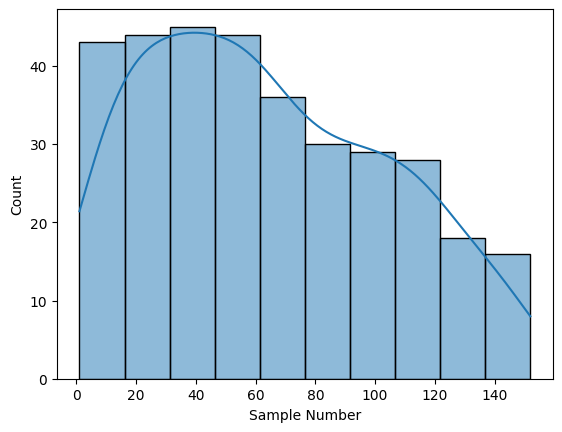

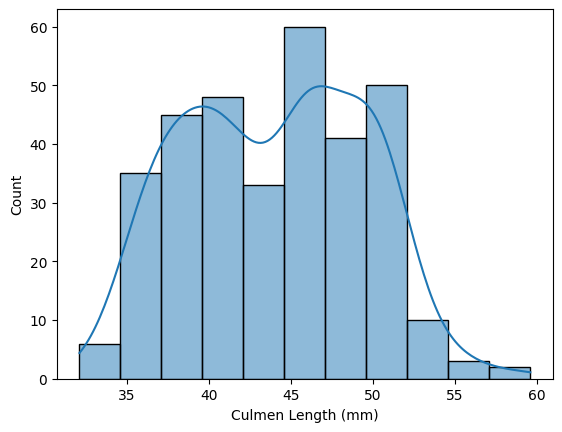

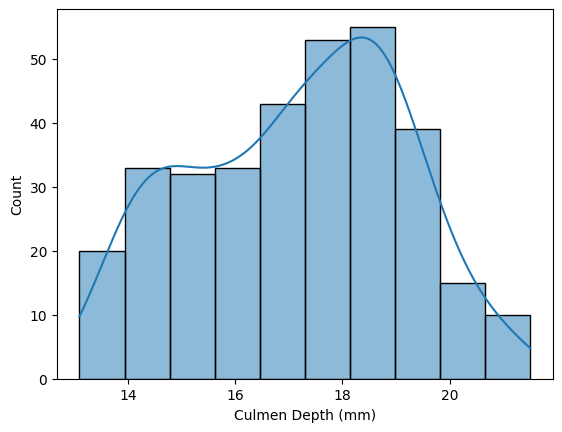

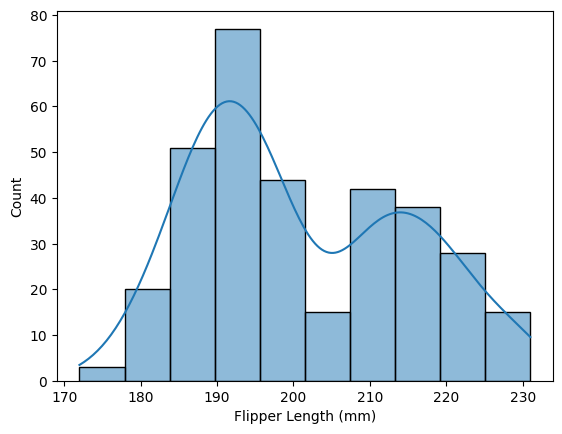

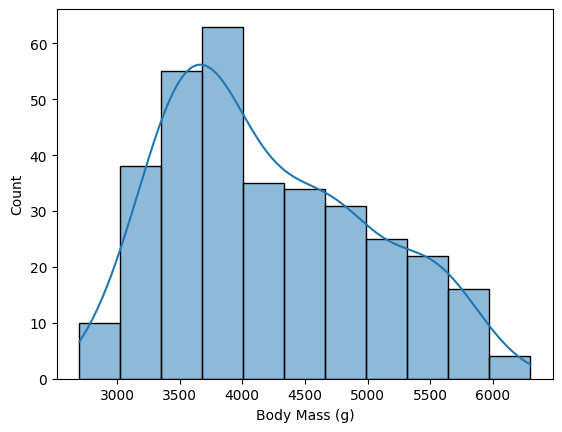

In [21]:
for col in df.select_dtypes(include='number').columns:
    sns.histplot(data=df, x=col, kde=True)
    plt.show()

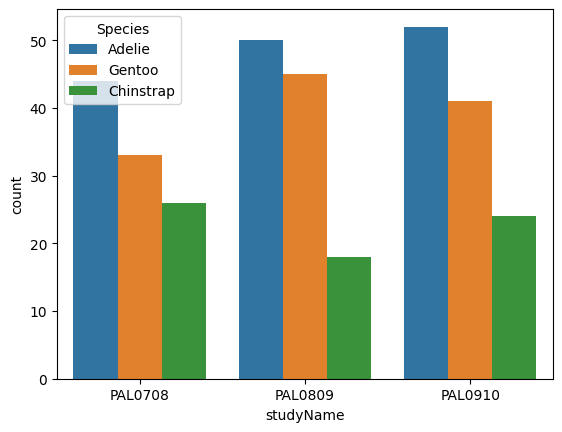

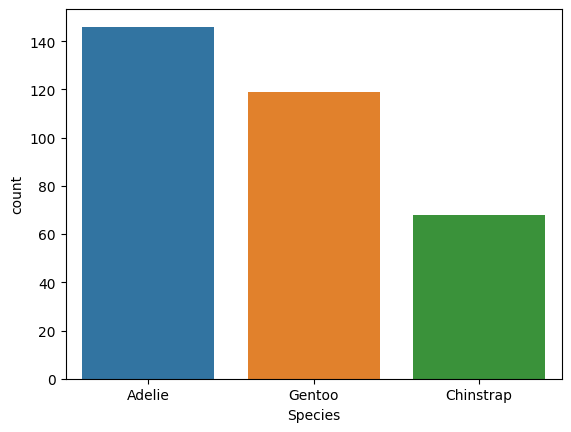

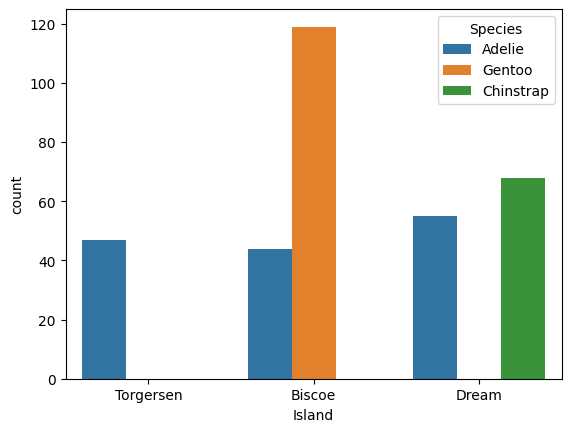

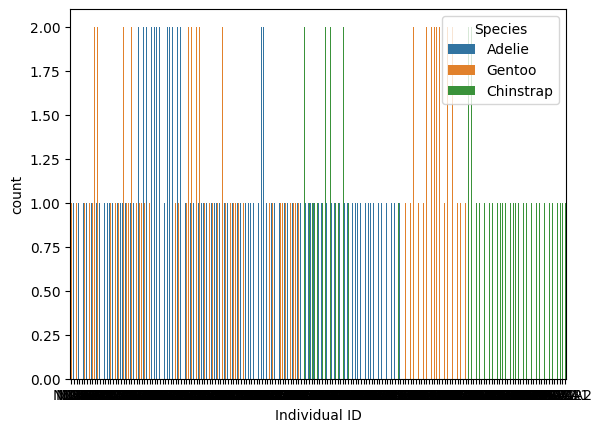

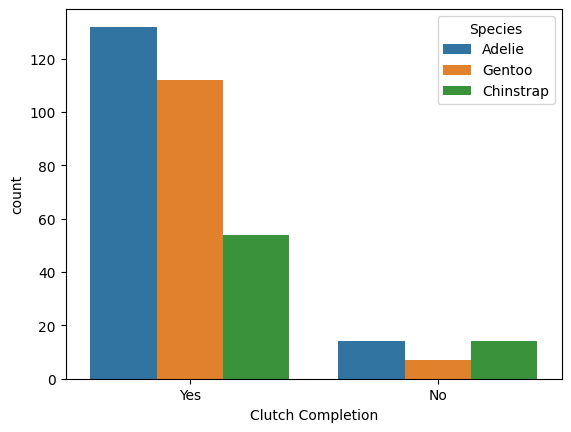

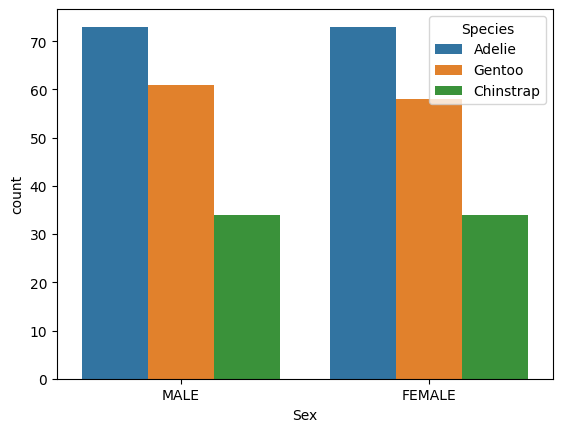

In [22]:
for col in df.select_dtypes(include='object').columns:
    sns.countplot(data=df, x=col, hue='Species')
    plt.show()

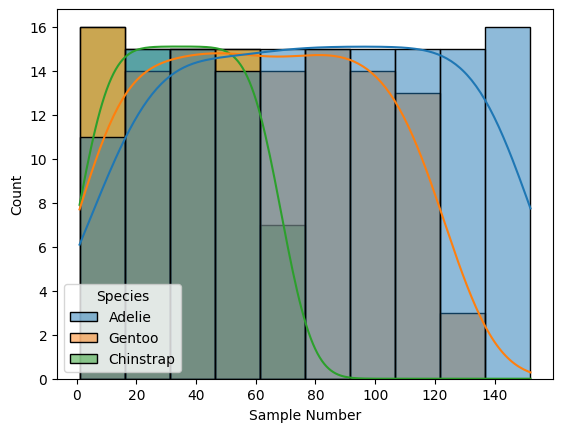

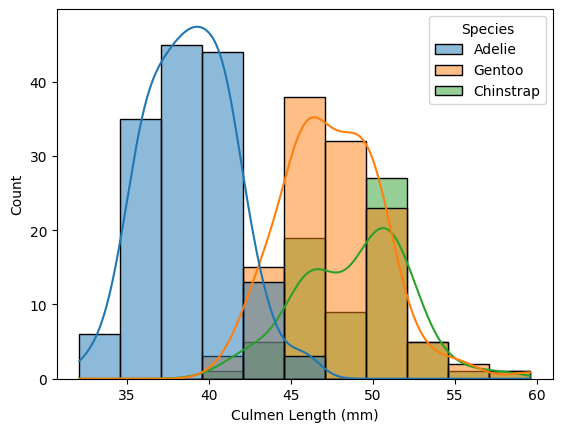

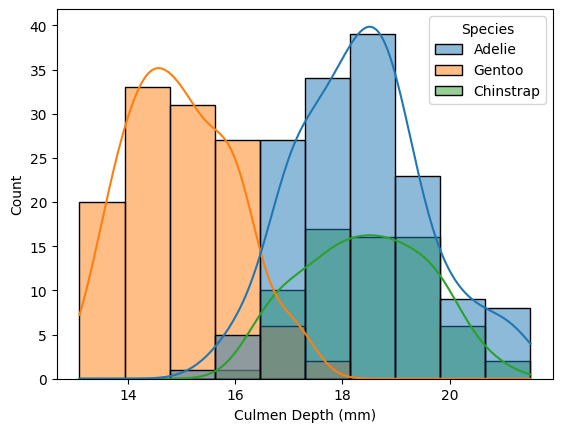

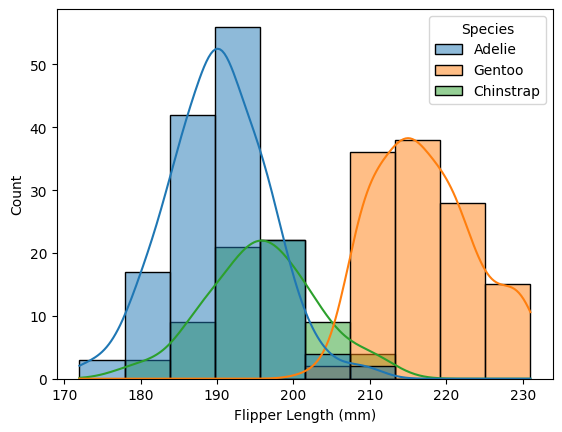

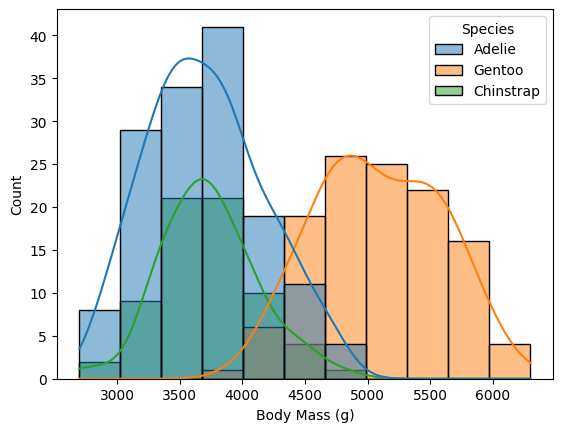

In [23]:
for col in df.select_dtypes(include='number').columns:
    sns.histplot(data=df, x=col, kde=True, hue='Species')
    plt.show()

<Axes: xlabel='Culmen Length (mm)', ylabel='Culmen Depth (mm)'>

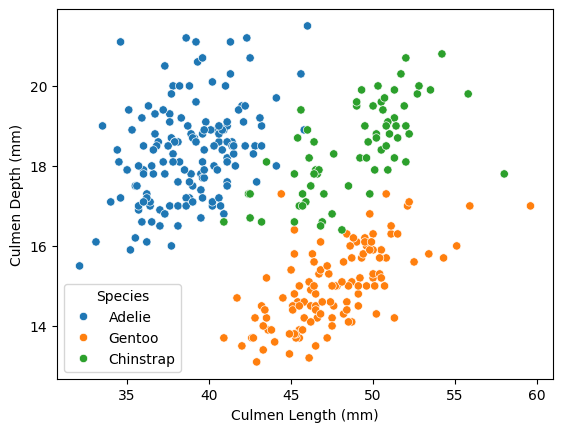

In [24]:
sns.scatterplot(data=df, x='Culmen Length (mm)', y='Culmen Depth (mm)', hue='Species')


In [25]:
df[['Culmen Length (mm)' ,'Culmen Depth (mm)']].corr()

,Culmen Length (mm),Culmen Depth (mm)
Culmen Length (mm),1.000000,-0.228626
Culmen Depth (mm),-0.228626,1.000000


In [26]:
df[df['Species'] == 'Adelie'][['Culmen Length (mm)' ,'Culmen Depth (mm)']].corr()

,Culmen Length (mm),Culmen Depth (mm)
Culmen Length (mm),1.000000,0.385813
Culmen Depth (mm),0.385813,1.000000


In [28]:
fig = px.histogram(df, x="Island", color="Species", barmode="group", title="Species Distribution per Island")
fig.show()